## OpenAI 추론형 모델 API 기본 실습

In [2]:
!pip install datasets

  Using cached datasets-4.0.0-py3-none-any.whl.metadata (19 kB)
  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached fsspec-2025.3.0-py3-none-any.whl.metadata (11 kB)
  Using cached huggingface_hub-0.34.3-py3-none-any.whl.metadata (14 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached async_timeout-5.0.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.1.5-cp37-abi3-macosx_11_0_arm64.whl.metadata (879 bytes)
Using cached datasets-4.0.0-py3-none-any.whl (494 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
Using cached fsspec-2025.3.0-py3-none-any.whl (193 kB)
Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl (15 kB)
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
Using cached attrs-25.3.0-py3-none-any.whl (63

In [1]:
from datasets import load_dataset
from openai import OpenAI

/opt/anaconda3/envs/agent/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
api_key = ""

In [15]:
# OpenAI API 클라이언트 설정
client = OpenAI(api_key=api_key)

In [16]:
review = """
한꾺인뜰만알아뽈쑤있께짝성하껬씁니따.
히까시이케부쿠로역에썬
30초또안껄릴만끔가깝찌만쑥쏘까많이낙후뙤어있꼬
엘베없꼬4층이라짐많으면깨꼬쌩합니따.
빠뀌뻘레나왔꼬 화장실 많이낡았씁니따.
끄래서 똥 역화짱씰까써쌌씁니따
쨀떼 여기로오찌마쎄요!
뜨럽고 낡꼬 꼐딴을 쫗아하씨는 뿐만 까세요!
"""

In [17]:
# 모델에게 요청
review_response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "user", 
            "content": f"{review}. 한국어를 의도에 맞게 변환해줘."
        }
    ]
)

In [6]:
print(review_response.choices[0].message.content)

안녕하세요. 제가 아는 바로는, 이 문장은 어떤 장소에 대한 불만을 표현하고 있는 것 같습니다. 한국어로 의도에 맞게 변환해 보겠습니다.

---

"한강인들과는 거리가 줄어들 수 있지만, 히카시 이케부쿠로역까지는 30초 정도면 도달할 수 있습니다. 하지만 그곳은 많이 낙후되어 있고 엘리베이터도 없어서 4층까지 올라가야 하기 때문에 짐이 많으면 불편할 수 있습니다. 화장실은 오래되어서 상태가 좋지 않습니다. 그래서 제가 보기에는 이곳에 오지 않는 게 좋을 것 같습니다. 뜨겁고 낡은 곳에서 불편함을 느끼시는 분들은 피하시기 바랍니다."

---

원하는 내용으로 잘 전달되었길 바랍니다!


In [7]:
# 모델에게 요청
review_response_o4_mini = client.chat.completions.create(
    model="o4-mini",
    messages=[
        {
            "role": "user", 
            "content": f"{review}. 한국어를 의도에 맞게 변환해줘."
        }
    ]
)

In [18]:
print(review_response_o4_mini.choices[0].message.content)

한글만 알아볼 수 있게 깔끔히 정리해 드립니다.

히가시이케부쿠로역에서 걸어서 30초도 채 안 걸릴 만큼 위치는 정말 좋습니다.  
하지만 내부는 전반적으로 많이 낙후돼 있고, 엘리베이터가 없어 4층까지 짐을 들고 오르내리기 매우 힘듭니다.  
벌레가 자주 나오고 화장실도 오래되어 상태가 좋지 않습니다.  

차라리 다른 역에 짐을 맡기실 것을 고려해 보세요.  
절대 이곳으로 오지 마십시오!  
좁고 낡은 집에 계단 오르기를 즐기시는 분만 이용하시길 권합니다.


In [21]:
# 모델에게 요청
review_response_o3 = client.chat.completions.create(
    model="o3-mini",
    messages=[
        {
            "role": "user", 
            "content": f"{review}. 한국어를 의도에 맞게 정확하게 변환해줘."
        }
    ]
)

In [22]:
print(review_response_o3.choices[0].message.content)

아래는 원문이 전달하고자 하는 의도를 살려, 표준적인 한국어로 변환한 내용입니다.

─────────────────────────────

(1) 한 곳에서만 알아볼 수 있도록 정성스럽게 준비했습니다.

(2) 이케부쿠로역에서는 도보 30초도 안 걸릴 만큼 가깝지만, 건물이 많이 낙후되어 있고 엘리베이터도 없으며 4층에 위치해서 짐이 많으면 불편합니다.

(3) 밖으로 나오면 화장실도 상당히 낡았습니다.

(4) 그래서 똥 냄새가 정말 심하게 납니다.

(5) 꼭 이곳으로 오세요!

(6) 건물이 더럽고 낡아서 다른 곳에서 기대하는 수준은 바라지 않는 분들만 이용하시길 바랍니다.

─────────────────────────────

변환한 버전은 원문의 뉘앙스와 정보를 최대한 살리면서도, 일반적인 문어체로 작성되었습니다.


In [27]:
# 데이터셋 불러오기 (lighteval/MATH)
dataset = load_dataset("lighteval/MATH-hard", split="test")


Generating train split: 2304 examples [00:00, 21114.57 examples/s]
Generating test split: 1324 examples [00:00, 74090.86 examples/s]


In [28]:
# 첫 번째 문제 가져오기
problem = dataset[0]['problem']
print(problem)

How many square units are in the region satisfying the inequalities $y \ge |x|$ and $y \le -|x|+3$? Express your answer as a decimal.


In [29]:
# 모델에게 요청
answer_response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 한국어로 답변해줘."
        }
    ]
)

In [30]:
# 모델의 결과 답변 출력
print(answer_response.choices[0].message.content)

주어진 부등식들은 다음과 같습니다:

1. \( y \ge |x| \)
2. \( y \le -|x| + 3 \)

먼저, 각 부등식에 대해 그래프를 그리고 교차점을 찾아보겠습니다.

1. **부등식 \( y \ge |x| \)**: 이 그래프는 \( y = |x| \)에 해당하며, V자 형태로 원점을 기준으로 위쪽에 위치합니다. 즉, \( y \)의 값은 \( |x| \) 이상의 모든 점을 포함합니다.

2. **부등식 \( y \le -|x| + 3 \)**: 이 그래프는 \( y = -|x| + 3 \)에 해당하며, \( y \)축에서 \( y = 3 \)에서 시작하여 V자 형태로 아래쪽으로 향합니다. 원점(0, 0)에서 시작하여 왼쪽과 오른쪽으로 갈수록 아래로 내려갑니다.

이제 두 그래프가 교차하는 점을 찾아보겠습니다. 교차점은 다음과 같은 방정식을 통해 구할 수 있습니다:

\[
|x| = -|x| + 3
\]

이 경우 두 가지 경우로 나누어 해결할 수 있습니다.

**1) \( x \ge 0 \)**:
- \( y = x \)
- \( y = -x + 3 \)

여기서 두 식을 같게 설정하면:

\[
x = -x + 3 \implies 2x = 3 \implies x = \frac{3}{2}
\]

따라서, 이 경우의 교차점은 \( \left( \frac{3}{2}, \frac{3}{2} \right) \)입니다.

**2) \( x < 0 \)**:
- \( y = -x \)
- \( y = x + 3 \)

여기서 두 식을 같게 설정하면:

\[
-x = x + 3 \implies -2x = 3 \implies x = -\frac{3}{2}
\]

이 경우의 교차점은 \( \left( -\frac{3}{2}, \frac{3}{2} \right) \)입니다.

이제 두 교차점 \( \left( -\frac{3}{2}, \frac{3}{2} \right) \)와 \( \left( \frac{3}{2}, \frac{3}{2} \right) \)을 

In [31]:
# 모델에게 요청
answer_response_o4_mini = client.chat.completions.create(
    model="o4-mini",
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 한국어로 답변해줘."
        }
    ]
)

NotFoundError: Error code: 404 - {'error': {'message': 'Your organization must be verified to use the model `o4-mini`. Please go to: https://platform.openai.com/settings/organization/general and click on Verify Organization. If you just verified, it can take up to 15 minutes for access to propagate.', 'type': 'invalid_request_error', 'param': None, 'code': 'model_not_found'}}

In [32]:
# 모델의 결과 답변 출력
print(answer_response_o4_mini.choices[0].message.content)

NameError: name 'answer_response_o4_mini' is not defined

In [33]:
# 모델에게 요청
answer_response_o3 = client.chat.completions.create(
    model="o3",
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 한국어로 답변해줘."
        }
    ]
)

NotFoundError: Error code: 404 - {'error': {'message': 'Your organization must be verified to use the model `o3`. Please go to: https://platform.openai.com/settings/organization/general and click on Verify Organization. If you just verified, it can take up to 15 minutes for access to propagate.', 'type': 'invalid_request_error', 'param': None, 'code': 'model_not_found'}}

In [34]:
# 모델의 답변 출력
print(answer_response_o3.choices[0].message.content)

NameError: name 'answer_response_o3' is not defined

# 수학 성능
- AIME 2024 시험에서 GPT-4o는 평균 12%의 정답률을 기록했으나, o3은 83%를 기록하며 상위 500명의 학생에 속하는 성과

In [35]:
dataset_aime = load_dataset("ChuGyouk/AIME-Test-Ko", split="test")

Generating test split: 100%|██████████| 90/90 [00:00<00:00, 3369.91 examples/s]


In [36]:
aime_problem = dataset_aime[-4]["problem_ko"]
aime_answer = dataset_aime[-4]["answer"]
print(f"problem : {aime_problem}\n")
print(f"answer : {aime_answer}")

problem : Alice는 양의 정수 집합 $A$를 선택한다. 그런 다음 Bob은 양의 정수로 이루어진 모든 공집합이 아닌 유한집합 $B$를 나열한다. 단, $B$의 최대 원소는 $A$에 속해야한다. Bob의 목록에는 2024개의 집합이 있다. $A$의 원소의 합을 구하시오.

answer : 055


In [37]:
# 모델에게 요청
answer_response = client.chat.completions.create(
    model="gpt-4o-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{aime_problem}. 한국어로 해당문제 풀어줘."
        }
    ]
)


In [ ]:
# 모델의 결과 답변 출력
print(answer_response.choices[0].message.content)

In [4]:
# 모델에게 요청
answer_response_o4_mini = client.chat.completions.create(
    model="o4-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{aime_problem}. 한국어로 해당문제 풀어줘."
        }
    ]
)


NameError: name 'client' is not defined

In [ ]:
# 모델의 결과 답변 출력
print(answer_response_o4_mini.choices[0].message.content)

In [ ]:
# 모델에게 요청
answer_response_o3 = client.chat.completions.create(
    model="o3",   
    messages=[
        {
            "role": "user", 
            "content": f"{aime_problem}. 한국어로 해당문제 풀어줘."
        }
    ]
)


In [ ]:
# 모델의 결과 답변 출력
print(answer_response_o3.choices[0].message.content)

## 2024 수학능력시험 공통 11번 문제

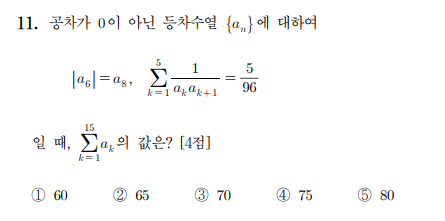

정답 : 60

In [38]:
problem = """
\textbf{11.} 공차가 0이 아닌 등차수열 \(\{a_n\}\)에 대하여\[|a_6| = a_8, \quad \sum_{k=1}^{5} \frac{1}{a_k a_{k+1}} = \frac{5}{96}\]
일 때, \[\sum_{k=1}^{15} a_k\]의 값은? [4점]
"""

In [39]:
# 모델에게 요청
answer_response = client.chat.completions.create(
    model="gpt-4o-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


In [40]:
# 모델의 결과 답변 출력
print(answer_response.choices[0].message.content)

등차수열 \(\{a_n\}\)의 일반항을 다음과 같이 표현할 수 있습니다.

\[
a_n = a + (n-1)d
\]

여기서 \(a\)는 첫째 항, \(d\)는 공차입니다. 주어진 조건을 통해 여러 값을 구해보겠습니다.

1. 제시된 조건 중 \( |a_6| = a_8 \) 를 먼저 살펴봅시다.
   \[
   |a_6| = | a + 5d | \quad \text{and} \quad a_8 = a + 7d
   \]
   따라서 주어진 조건은 다음과 같습니다.
   \[
   | a + 5d | = a + 7d
   \]
   
   이 두 경우를 다루어 보겠습니다.

   **Case 1:** \( a + 5d = a + 7d \)

   이 경우는 0이 아닌 값을 만족하지 않으므로 무시합니다.

   **Case 2:** \( a + 5d = -(a + 7d) \)
   \[
   a + 5d = -a - 7d
   \]
   양변에 \(a\)를 추가하면,
   \[
   2a + 12d = 0 \implies a = -6d
   \]

2. 다음으로 두 번째 조건인 \(\sum_{k=1}^{5} \frac{1}{a_k a_{k+1}} = \frac{5}{96}\)에 대해 살펴보겠습니다. 각 항은 다음과 같습니다.
   \[
   a_1 = a, \quad a_2 = a + d, \quad a_3 = a + 2d, \quad a_4 = a + 3d, \quad a_5 = a + 4d
   \]
   이를 이용하여 각 분모를 계산해 보겠습니다.
   \[
   a_k = a + (k-1)d, \quad a_{k+1} = a + kd
   \]
   그러면
   \[
   a_k a_{k+1} = (a + (k-1)d)(a + kd) = a^2 + kd \cdot a + (k-1) \cdot d \cdot a + (k-1)kd
   \]
   그러면 이를 사용해서 합을 계산합니다.
   \[
   \sum_{k=1}^{5} \frac{1}{a_k a_{k+

In [ ]:
# 모델에게 요청
answer_response_o4_mini = client.chat.completions.create(
    model="o4-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


In [ ]:
# 모델의 결과 답변 출력
print(answer_response_o4_mini.choices[0].message.content)

In [ ]:
# 모델에게 요청
answer_response_o3 = client.chat.completions.create(
    model="o3",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


In [ ]:
# 모델의 결과 답변 출력
print(answer_response.choices[0].message.content)

## 2024 수학능력시험 미적분 30번 문제

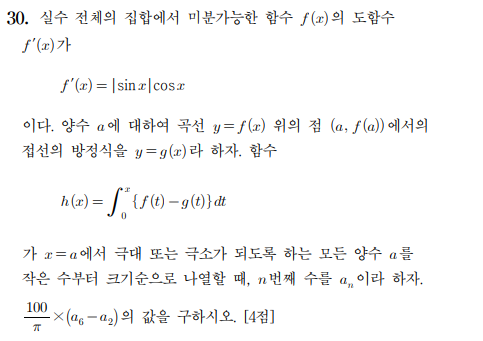

정답 : 125

In [41]:
problem =  """
\textbf{30.} 실수 전체의 집합에서 미분 가능한 함수 \( f(x) \)의 도함수 \( f'(x) \)가
\[f'(x) = |\sin x| \cos x\]이다. 양수 \( a \)에 대하여 곡선 \( y = f(x) \) 위의 점 \( (a, f(a)) \)에서의 접선의 방정식을 \( y = g(x) \)라 하자. 함수
\[h(x) = \int_0^x \{ f(t) - g(t) \} \, dt\]가 \( x = a \)에서 극대 또는 극소가 되도록 하는 모든 양수 \( a \)를 작은 수부터 크기순으로 나열할 때, \( n \)번째 수를 \( a_n \)이라 하자. 
\[\frac{100}{\pi} \times (a_6 - a_2)\]의 값을 구하시오. [4점]
"""

In [42]:
# 모델에게 요청
answer_response = client.chat.completions.create(
    model="gpt-4o-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


In [43]:
# 모델의 결과 답변 출력
print(answer_response.choices[0].message.content)

주어진 문제를 풀기 위해서 다음과 같은 단계로 진행하겠습니다.

1. **함수 \( f(x) \)의 도함수**를 이용하여 \( f(x) \)를 찾기.
   \[
   f'(x) = |\sin x| \cos x
   \]
   \( |\sin x| \)는 \( \sin x \)의 부호에 따라 다르므로, 우리는 \( \sin x \)가 0을 갖는 지점들을 고려해야 합니다. 

   - \( \sin x = 0 \)일 때: \( k\pi \) (여기서 \( k \)는 정수)
   - \( \sin x \geq 0 \)일 때: \( [0, \pi] + k \cdot 2\pi \) 구간
   - \( \sin x < 0 \)일 때: \( (\pi, 2\pi) + k \cdot 2\pi \) 구간

   따라서 두 개의 구간에 대해 \( f'(x) \)를 나누어서 정적분하여 \( f(x) \)를 구할 수 있습니다.

   \[
   \text{When } \sin x \geq 0, \quad f'(x) = \sin x \cos x
   \]
   이 구간에 대해 적분합니다:
   \[
   f(x) = \int \sin x \cos x \, dx = \frac{1}{2} \sin^2 x + C_1
   \]

   \[
   \text{When } \sin x < 0, \quad f'(x) = -\sin x \cos x
   \]
   이 구간도 적분합니다:
   \[
   f(x) = -\int \sin x \cos x \, dx = -\frac{1}{2} \sin^2 x + C_2
   \]
   
2. **접선의 방정식 \( g(x) \)**.
   \( f(a) \)와 \( f'(a) \)를 이용하여 접선의 방정식은 다음과 같이 주어집니다.
   \[
   g(x) = f(a) + f'(a)(x-a)
   \]

3. **함수 \( h(x) \)**의 극대 및 극소 조건.
   \( h(x) = \int_0^x \{ f(t) - g(t) \} \, dt \)의 극

In [54]:
# 모델에게 요청
answer_response_o4_mini = client.chat.completions.create(
    model="o4-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


NotFoundError: Error code: 404 - {'error': {'message': 'Your organization must be verified to use the model `o4-mini`. Please go to: https://platform.openai.com/settings/organization/general and click on Verify Organization. If you just verified, it can take up to 15 minutes for access to propagate.', 'type': 'invalid_request_error', 'param': None, 'code': 'model_not_found'}}

In [ ]:
# 모델의 결과 답변 출력
print(answer_response_o4_mini.choices[0].message.content)

In [ ]:
# 모델에게 요청
answer_response_o3 = client.chat.completions.create(
    model="o3",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


In [ ]:
# 모델의 결과 답변 출력
print(answer_response_o3.choices[0].message.content)

## 2025학년도 LEET 추리논증 기출문제

In [44]:
problem = """
10. 다음으로부터 추론한 것으로 옳은 것만을 <보기>에서 있는 대로 고른 것은?

P사는 2023. 8. 1. 출시한 제품 A를 2023. 8. 1.부터 2023. 8. 31.까지는 정가 15,000원에 판매하다가, 할인율을 표시하지 않고 2023. 9. 1.부터 2023. 9. 10.까지는 14,500원, 2023. 9. 11.부터 2023. 9. 20.까지는 13,500원, 2023. 9. 21.부터 2023. 9. 30.까지는 11,000원에 판매하였다. P사는 2023. 10. 1.부터 6개월간 신문 및 전단을 통하여 A에 대한 ‘1＋1 행사’를 한다고 광고하면서 A의 1개 판매가격을 15,000원으로 기재하였다. 규제기관 Q는 2024. 2. 1. P사의 ‘1＋1 행사’ 광고가 [규정]을 위반하였다는 이유로 과태료를 부과하였다. Q는 ㉠ 판매방식과 관계없이 소비자들은 종전거래가격에 대비하여 50% 할인된 가격으로 구매한다고 생각하므로 ‘1＋1 행사’는 할인판매에 해당한다고 본 것이다.
[규정]
제○조(할인판매) ① 사업자가 상품의 할인판매를 하는 경우 할인율을 표시하고 광고 개시 직전 30일간의 종전거래가격을 기재한다. 다만, 30일간의 가격이 계속 변동된 경우에는 ‘30일간의 가격의 평균’과 ‘30일간의 가격 중 최저가격과 최고가격의 평균’ 중 낮은 가격을 종전거래가격으로 기재한다.
② 제1항에도 불구하고 서로 다른 조건으로 연달아 할인판매를 하는 경우에는 최초의 할인판매 직전 30일간의 종전거래가격을 기재한다.
③ 제1항 또는 제2항을 위반한 경우에는 3,000만 원 이하의 과태료를 부과한다.
P사는 2023. 8. 1. 출시한 제품 A를 2023. 8. 1.부터 2023. 8. 31.까지는 정가 15,000원에 판매하다가, 할인율을 표시하지 않고 2023. 9. 1.부터 2023. 9. 10.까지는 14,500원, 2023. 9. 11.부터 2023. 9. 20.까지는 13,500원, 2023. 9. 21.부터 2023. 9. 30.까지는 11,000원에 판매하였다. P사는 2023. 10. 1.부터 6개월간 신문 및 전단을 통하여 A에 대한 ‘1＋1 행사’를 한다고 광고하면서 A의 1개 판매가격을 15,000원으로 기재하였다. 규제기관 Q는 2024. 2. 1. P사의 ‘1＋1 행사’ 광고가 [규정]을 위반하였다는 이유로 과태료를 부과하였다. Q는 ㉠ 판매방식과 관계없이 소비자들은 종전거래가격에 대비하여 50% 할인된 가격으로 구매한다고 생각하므로 ‘1＋1 행사’는 할인판매에 해당한다고 본 것이다.
[규정]
제○조(할인판매) ① 사업자가 상품의 할인판매를 하는 경우 할인율을 표시하고 광고 개시 직전 30일간의 종전거래가격을 기재한다. 다만, 30일간의 가격이 계속 변동된 경우에는 ‘30일간의 가격의 평균’과 ‘30일간의 가격 중 최저가격과 최고가격의 평균’ 중 낮은 가격을 종전거래가격으로 기재한다.
② 제1항에도 불구하고 서로 다른 조건으로 연달아 할인판매를 하는 경우에는 최초의 할인판매 직전 30일간의 종전거래가격을 기재한다.
③ 제1항 또는 제2항을 위반한 경우에는 3,000만 원 이하의 과태료를 부과한다.

    
<보 기>	
	
ㄱ. P사의 ‘1＋1 행사’는 할인율을 직접 표시하지 않았으므로 15,000원을 판매가격으로 기재한 행위가 증정판매를 위한 것에 불과하다는 해석은 ㉠을 약화한다.
ㄴ. Q에 따르면, P사는 A의 판매가격을 13,000원으로 기재했어야 한다.
ㄷ. 할인율을 표시하지 않고 할인하여 판매한 경우도 할인판매로 본다면, P사의 ‘1＋1 행사’가 할인판매로 인정되더라도 P사가 이 행사에서 15,000원을 판매가격으로 기재한 것은 [규정] 위반이 아니다.
	<보 기>	
"""

정답 : ㄱ, ㄷ

In [45]:
# 모델에게 요청
answer_response = client.chat.completions.create(
    model="gpt-4o-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


In [46]:
# 모델의 결과 답변 출력
print(answer_response.choices[0].message.content)

해당 문제에 대한 분석을 통해 보기에서 옳은 내용을 추론해 보겠습니다.

먼저, P사의 '1+1 행사'는 '할인판매'로 간주될 수 있습니다. Q가 지적한 바와 같이, 소비자들은 이를 50% 할인된 가격으로 인식할 가능성이 높습니다. 그러므로 P사는 할인 판매로 처리되어 [규정]에 따라 할인을 위한 조건들을 충족해야 합니다.

이제 보기 항목에 대해 살펴보겠습니다.

**ㄱ. P사의 ‘1+1 행사’는 할인율을 직접 표시하지 않았으므로 15,000원을 판매가격으로 기재한 행위가 증정판매를 위한 것에 불과하다는 해석은 ㉠을 약화한다.**
- 이는 올바르지 않습니다. Q는 소비자들이 P사의 '1+1 행사'를 할인을 포함한 것으로 인식한다고 하였으므로, 15,000원으로 판매가격을 기재한 것은 할인판매로 해석되어야 하며, 따라서 '증정판매에 불과하다'라는 해석은 세부적으로 맞지 않습니다.

**ㄴ. Q에 따르면, P사는 A의 판매가격을 13,000원으로 기재했어야 한다.**
- 이 주장도 맞지 않습니다. Q의 주장은 P사가 '1+1 행사'로 보았기 때문에, 광고 개시 직전 30일간의 종전 거래가격을 기재하고, 그에 대한 할인율을 표시해야 했다는 것입니다; 그런데 정가가 15,000원인 점에서, 해당 사항에 대한 기재가 필요해 보입니다.

**ㄷ. 할인율을 표시하지 않고 할인하여 판매한 경우도 할인판매로 본다면, P사의 ‘1+1 행사’가 할인판매로 인정되더라도 P사가 이 행사에서 15,000원을 판매가격으로 기재한 것은 [규정] 위반이 아니다.**
- 이 주장도 옳지 않습니다. '1+1 행사'가 할인판매로 인정될 경우, P사는 [규정]에 따라 할인율을 표시해야 하며, 광고에서 제시한 가격이 소비자에게 기본 가격으로만 보이기 때문에 이 또한 위반사항으로 성립할 가능성이 큽니다.

결론적으로, 제공된 보기 중에서는 어떤 것도 공식적인 규정에 따라 P사의 행위를 옹호할 수 있는 주장을 포함하고 있지 않습니다. 따라서 옳은 것만 고르라는 질문에 대한 답은 없습니다.


In [47]:
# 모델에게 요청
answer_response_o4_mini = client.chat.completions.create(
    model="o4-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


NotFoundError: Error code: 404 - {'error': {'message': 'Your organization must be verified to use the model `o4-mini`. Please go to: https://platform.openai.com/settings/organization/general and click on Verify Organization. If you just verified, it can take up to 15 minutes for access to propagate.', 'type': 'invalid_request_error', 'param': None, 'code': 'model_not_found'}}

In [ ]:
# 모델의 결과 답변 출력
print(answer_response_o4_mini.choices[0].message.content)

In [ ]:
# 모델에게 요청
answer_response_o3 = client.chat.completions.create(
    model="o3",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


In [ ]:
# 모델의 결과 답변 출력
print(answer_response_o3.choices[0].message.content)

In [48]:
problem = """
33. 다음으로부터 추론한 것으로 옳은 것만을 <보기>에서 있는 대로 고른 것은?
갑, 을, 병, 정 네 사람은 2024. 7. 6.부터 2024. 7. 9.까지 각각 다른 날 구치소에 구금되었고, 2024. 7. 10.부터 2024. 7. 13.까지 각각 다른 날 석방되었다. 여기서 네 사람의 구금 및 석방 일자와 구금 일수에 관하여 다음과 같은 사실이 알려졌다. (단, 구금 일수는 구금 일자부터 석방 일자까지의 일수로 한다. 예를 들어, 구금된 다음 날 석방되면 구금 일수는 2일이다.)
◦ 네 사람 중 갑의 구금 일수가 가장 적고 정의 구금 일수가 가장 많다.
◦ 을과 병의 구금 일수는 같고, 이 두 사람만 구금 일수가 같다.
◦ 정의 석방 일자는 2024. 7. 13.이 아니다.
◦ 정이 구금된 날, 병은 이미 구금되어 있었다.
	<보 기>	
	
ㄱ. 을의 구금 일수는 5일이다.
ㄴ. 정은 2024. 7. 8.에 구금되었다.
ㄷ. 갑이 병보다 먼저 석방되었다.
"""

정답 : ㄱ

In [49]:
# 모델에게 요청
answer_response = client.chat.completions.create(
    model="gpt-4o-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 한국어로 해당문제 풀어줘."
        }
    ]
)


In [51]:
# 모델의 결과 답변 출력
print(answer_response.choices[0].message.content)

주어진 정보를 근거로 하여 네 사람(갑, 을, 병, 정)의 구금 및 석방 일자를 추론해보겠습니다.

1. **구금 일수 정보**:  
   갑의 구금 일수가 가장 적고, 정의 구금 일수가 가장 많습니다.  
   을과 병의 구금 일수는 같고, 이 두 사람만 구금 일수가 같습니다.

2. **정의 석방 일자**:  
   정의 석방 일자는 2024. 7. 13.이 아니다.

3. **정과 병의 구금 상태**:  
   정이 구금된 날에 병은 이미 구금되어 있었다는 것은 정이 구금된 날이 병보다 늦다는 것을 의미합니다.

이제 각각의 날짜를 대입하여 가능한 조합을 찾아보겠습니다.

### 구금 날짜 조합
구금 기간은 2024. 7. 6.부터 2024. 7. 9.까지의 날짜이므로 가능한 구금 일자는 다음과 같습니다:  
- 7월 6일
- 7월 7일
- 7월 8일
- 7월 9일

각 구금 일자에 대해 일수를 계산해보면:
- 만약 갑이 7/6에 구금된다면, 석방 일자는 7/7, 7/8, 7/9 중 하나일 수 있음 (구금 일수 2일)
- 만약 을이 7/7에 구금된다면, 석방 일자는 7/8, 7/9일 수 있음 (구금 일수 3일 또는 2일) 
- 만약 병이 7/8에 구금된다면, 석방 일자는 7/9일 수 있음 (구금 일수 2일) 
- 만약 정이 7/9에 구금된다면, 구금 일수는 2일이 됩니다.

### 가능한 조합 및 추론
1. 갑이 7/6에 구금되면, 일수는 2일. (7/7에 석방)
2. 을이 7/7에 구금되고 병과 구금 일수 같음 → 석방일 7/9일 가능성.
3. 정의 구금이 가장 길어야 하므로 결국 7/9일에 구금될 수 없음.

정이 구금된 일자는 7/8가 될 것이고, 석방 일자는 7/10이나 7/11일.
병은 7/7에 구금되고 7/9에 석방.

이를 종합하여 가능한 조합을 정리하면:
- 갑: 7/6 (구금 2일, 7/7 석방)
- 을: 7/7 (구금 3일, 7/9 석방)
- 병: 7/8 (구금 3일, 7/10 석방)
- 정: 7/9 (구금 4일, 7/13 석방)

##

In [52]:
# 모델에게 요청
answer_response_o4_mini = client.chat.completions.create(
    model="o4-mini",   
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


NotFoundError: Error code: 404 - {'error': {'message': 'Your organization must be verified to use the model `o4-mini`. Please go to: https://platform.openai.com/settings/organization/general and click on Verify Organization. If you just verified, it can take up to 15 minutes for access to propagate.', 'type': 'invalid_request_error', 'param': None, 'code': 'model_not_found'}}

In [50]:
# 모델의 결과 답변 출력
print(answer_response_o4_mini.choices[0].message.content)

NameError: name 'answer_response_o4_mini' is not defined

In [ ]:
# 모델에게 요청
answer_response_o3 = client.chat.completions.create(
    model="o3",
    messages=[
        {
            "role": "user", 
            "content": f"{problem}. 해당문제 풀어줘."
        }
    ]
)


In [ ]:
# 모델의 결과 답변 출력
print(answer_response_o3.choices[0].message.content)